In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [3]:
AAPL = pd.read_csv("../data/AAPL.csv", parse_dates=["Date"])
GOOG = pd.read_csv("../data/GOOG.csv", parse_dates=["Date"])
AMZN = pd.read_csv("../data/AMZN.csv", parse_dates=["Date"])
META = pd.read_csv("../data/META.csv", parse_dates=["Date"])
MSFT = pd.read_csv("../data/MSFT.csv", parse_dates=["Date"])
NVDA = pd.read_csv("../data/NVDA.csv", parse_dates=["Date"])


In [5]:
raw_analyst_ratings = pd.read_csv("../data/raw_analyst_ratings.csv", parse_dates=["date"],index_col=0)

In [4]:
raw_analyst_ratings

,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A
...,...,...,...,...,...
1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX
1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX
1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX
1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX


## 2. Descriptive Statistics on Text Lengths

2.1 Headline length

In [6]:
df = raw_analyst_ratings.copy()
df['headline_length'] = df['headline'].astype(str).apply(len)

# This forces normal decimal display for all floats
pd.set_option('display.float_format', '{:.2f}'.format)
df['headline_length'].describe()








count   1407328.00
mean         73.12
std          40.74
min           3.00
25%          47.00
50%          64.00
75%          87.00
max         512.00
Name: headline_length, dtype: float64

In [7]:
x=df[df['headline_length']==512]['headline'].iloc[0]
print(x)


JinkoSolar Tiger Pro Series Receives World's First IEC 61701 Ed. 3 (FDIS) Certification for Salt Mist Corrosion Standards JinkoSolar Holding Co., Ltd. (the "Company," or "JinkoSolar") (NYSE:JKS), one of the largest and most innovative solar module manufacturers in the world, today announced that its innovative Tiger Pro Series of high-efficiency modules received the world's first IEC 61701 Ed. 3 (FDIS) certification for salt mist corrosion test issued by TÜV Nord AG, an independent provider of technical ser


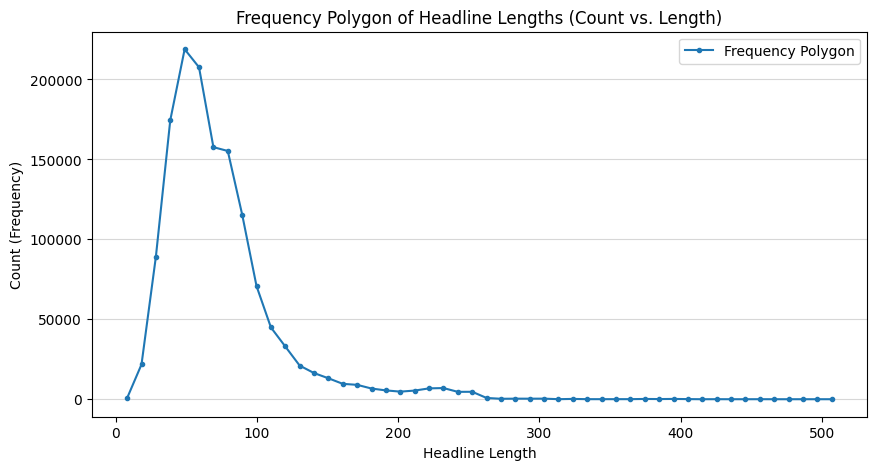

In [8]:

# --- Assuming 'df' is your DataFrame loaded with data ---
# Get the data Series
data_series = df['headline_length'] 

# 1. Calculate the counts and bin edges (the basis of a histogram)
# We use 50 bins to match your previous request
counts, bin_edges = np.histogram(data_series, bins=50)

# 2. Calculate the center point for each bin. This will be your X-axis.
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 3. Use plt.plot() to create the line graph (Frequency Polygon)
plt.figure(figsize=(10, 5))
plt.plot(bin_centers, counts, linestyle='-', marker='o', markersize=3, label='Frequency Polygon')



plt.title('Frequency Polygon of Headline Lengths (Count vs. Length)')
plt.xlabel('Headline Length')
plt.ylabel('Count (Frequency)')
plt.grid(axis='y', alpha=0.5)
plt.legend()
plt.show()


In [9]:
df

,headline,url,publisher,date,stock,headline_length
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87
...,...,...,...,...,...,...
1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX,38
1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX,52
1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX,56
1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX,54


2.2. Count Number of Articles per Publisher

In [10]:
publisher_counts = df['publisher'].value_counts()

publisher_counts.head(20)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

In [11]:
df[(df['publisher'].str.contains('benzinga', case=False))]

,headline,url,publisher,date,stock,headline_length
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42
5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00,A,71
6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 09:36:20-04:00,A,73
7,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22 09:07:04-04:00,A,120
...,...,...,...,...,...,...
1413780,"After Hours Losers (ADCT, ARUN, WTSLA, ZUMZ, FL)",https://www.benzinga.com/after-hours-center/43...,Benzinga Staff15,2009-11-19 00:00:00,ZUMZ,48
1413782,China Zenix Auto International Announces Inten...,https://www.benzinga.com/news/18/06/11886479/c...,Benzinga Newsdesk,2018-06-15 09:01:12-04:00,ZX,81
1413783,China Zenix Auto Shares Halted News Pending,https://www.benzinga.com/news/18/06/11876679/c...,Benzinga Newsdesk,2018-06-13 16:52:35-04:00,ZX,43
1413784,"China Zenix Auto Q1 EPS $0.08, Made $130.123M ...",https://www.benzinga.com/news/earnings/18/05/1...,Benzinga Newsdesk,2018-05-17 06:01:41-04:00,ZX,51


<Axes: xlabel='publisher'>

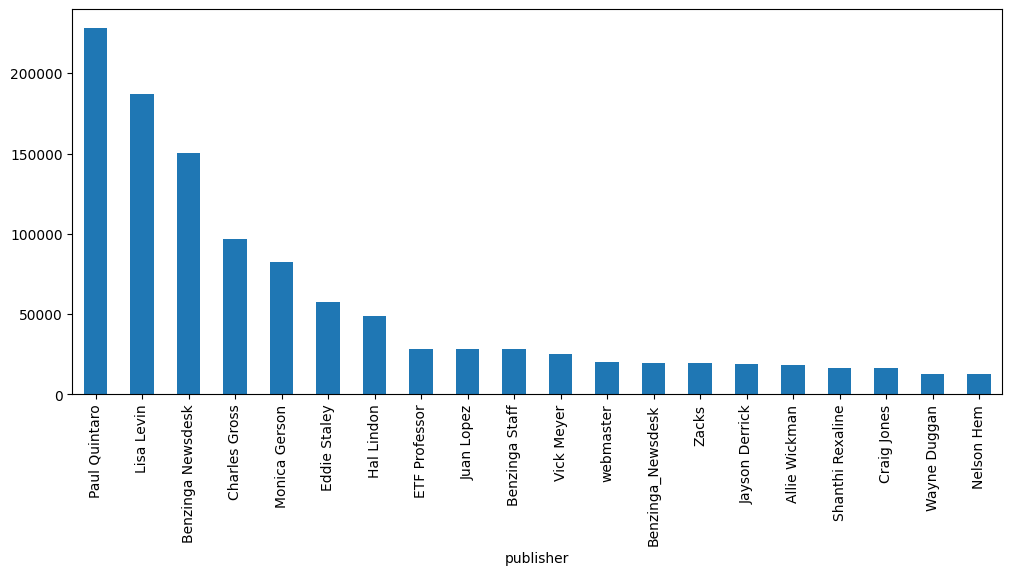

In [12]:
publisher_counts.head(20).plot(kind='bar', figsize=(12,5))


2.3 Publication Dates (Trends Over Time)

A) Convert date column properly

In [ ]:
"""check if the date is actually a date time and we notice that its an object and it contains datetime plus timezone mixedd with normal daytime, i assume they are in UTC already"""
df.info()

# # Create a new column that checks for timezone info
# df['has_timezone'] = df['date'].astype(str).str.contains(r'[\+\-][0-9]{2}:[0-9]{2}')

# # Count how many have vs don't have timezone
# df['has_timezone'].value_counts()


<class 'pandas.core.frame.DataFrame'>
Index: 1407328 entries, 0 to 1413848
Data columns (total 6 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   headline         1407328 non-null  object
 1   url              1407328 non-null  object
 2   publisher        1407328 non-null  object
 3   date             1407328 non-null  object
 4   stock            1407328 non-null  object
 5   headline_length  1407328 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 75.2+ MB


In [10]:
# df['date'] = (
#     pd.to_datetime(df['date'], format='mixed')
#     .dt.tz_convert('UTC', nonexistent='shift_forward', ambiguous='NaT')
# )

df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)
df['date']=df['date'].dt.tz_convert('UTC').dt.tz_localize(None)
df



,headline,url,publisher,date,stock,headline_length
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54,A,39
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20,A,42
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07,A,29
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06,A,44
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59,A,87
...,...,...,...,...,...,...
1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX,38
1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX,52
1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX,56
1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX,54


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1407328 entries, 0 to 1413848
Data columns (total 6 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   headline         1407328 non-null  object        
 1   url              1407328 non-null  object        
 2   publisher        1407328 non-null  object        
 3   date             1407328 non-null  datetime64[ns]
 4   stock            1407328 non-null  object        
 5   headline_length  1407328 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 75.2+ MB


In [22]:
df

,headline,url,publisher,date,stock,headline_length
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54,A,39
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20,A,42
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07,A,29
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06,A,44
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59,A,87
...,...,...,...,...,...,...
1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX,38
1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX,52
1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX,56
1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX,54


B) Extract time-based features

In [12]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()



df['year'].value_counts().sort_index(ascending=True)

year
2009     11489
2010     81319
2011    131322
2012    122649
2013    121529
2014    134859
2015    135295
2016    141892
2017    124456
2018    146924
2019    150380
2020    105214
Name: count, dtype: int64

📈 C) Trend: Articles

<Axes: title={'center': 'Articles per Year'}, xlabel='year'>

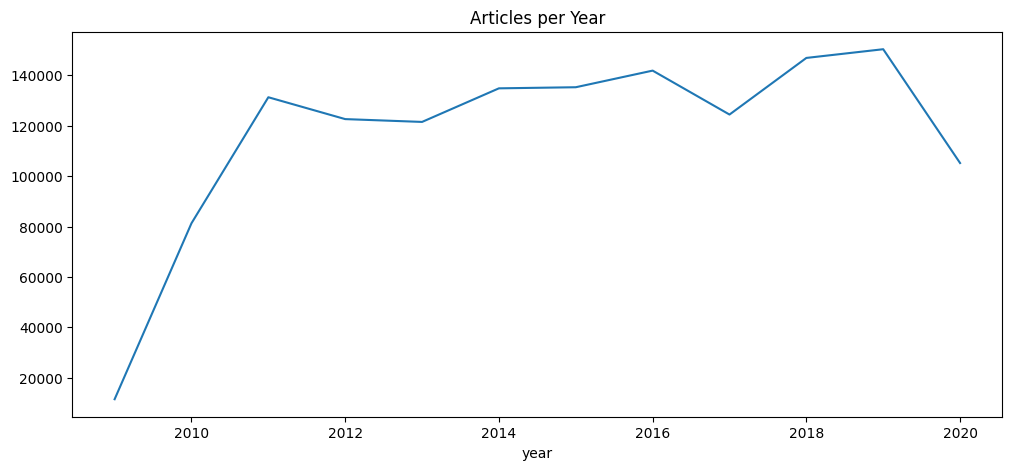

In [13]:
"""per year"""

articles_per_year = df.groupby('year').size()

articles_per_year.plot(kind='line', figsize=(12,5), title="Articles per Year")


month
1     121545
2     122836
3     121949
4     121813
5     130340
6     106598
7     110764
8     124041
9      96089
10    124800
11    121430
12    105123
dtype: int64


<Axes: title={'center': 'Articles per Month'}, xlabel='month'>

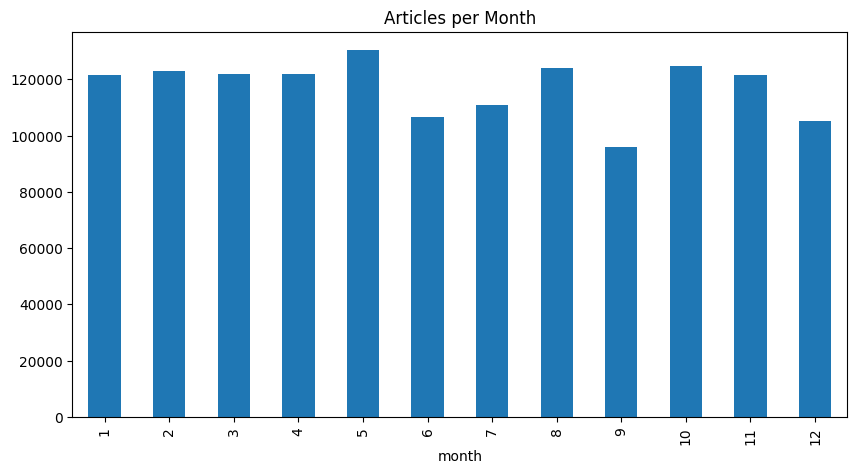

In [14]:
"""per month"""
articles_per_month = df.groupby('month').size()
print(articles_per_month)
articles_per_month.plot(kind='bar', figsize=(10,5), title="Articles per Month")


In [15]:
"""articless per weekdays"""

articles_per_weekday = df['weekday'].value_counts()

articles_per_weekday


weekday
Thursday     302619
Wednesday    300922
Tuesday      296505
Monday       265139
Friday       217918
Sunday        16466
Saturday       7759
Name: count, dtype: int64

<Axes: xlabel='date'>

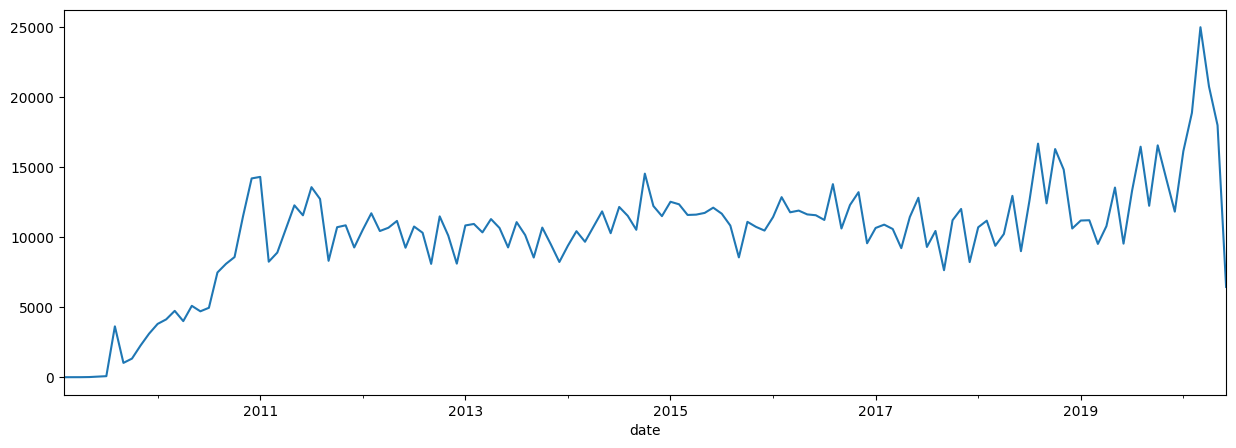

In [42]:
df.set_index('date').resample('ME').size().plot(figsize=(15,5))


<Axes: title={'center': 'Articles per period'}, xlabel='month/year'>

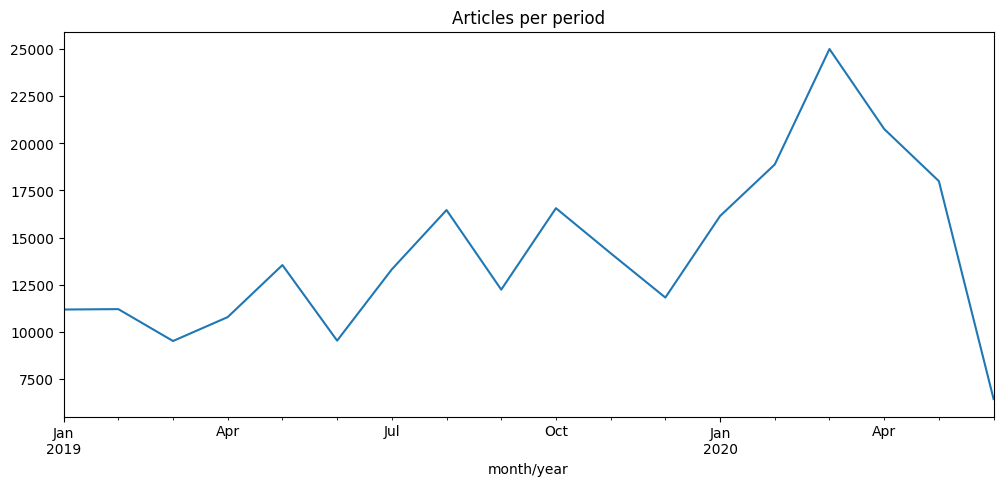

In [16]:
"""looked deeper into 2019 and 2020 because there was an interesting rise then decline between these years noticed the dataset is upto 6th month of 2020"""


filtered_years=df[df['date'].dt.year.isin([2020,2019])].copy()
filtered_years['month/year'] = filtered_years['date'].dt.to_period('M')
articles_per_month_filtered = filtered_years.groupby('month/year').size()
articles_per_month_filtered.plot(kind='line', figsize=(12,5), title="Articles per period")


In [17]:
articles_per_month_filtered

month/year
2019-01    11190
2019-02    11211
2019-03     9521
2019-04    10789
2019-05    13546
2019-06     9541
2019-07    13319
2019-08    16462
2019-09    12244
2019-10    16560
2019-11    14173
2019-12    11824
2020-01    16145
2020-02    18878
2020-03    24995
2020-04    20757
2020-05    17992
2020-06     6447
Freq: M, dtype: int64

In [18]:
df['date_only']=df['date'].dt.date

In [21]:
"""I noticed that the data is """


spike_dates=df['date_only'].value_counts().head(20)
spike_dates




date_only
2020-03-12    2739
2020-02-28    1620
2020-03-19    1595
2020-02-27    1567
2020-03-06    1428
2020-05-07    1398
2020-03-23    1391
2020-04-29    1389
2020-03-11    1384
2020-04-30    1327
2019-08-01    1270
2020-04-15    1253
2018-10-30    1228
2020-01-22    1198
2020-03-16    1181
2019-08-07    1180
2018-08-02    1175
2020-05-06    1175
2020-01-21    1171
2020-03-09    1170
Name: count, dtype: int64

| Date        | News Count | Key Event / Reason for High News Volume |
|-------------|------------|------------------------------------------|
| 2020-02-27  | 1567       | Stock Market Decline: Dow Jones dropped over 1,100 points, signaling major economic crisis fears. |
| 2020-02-28  | 1620       | Global Spread: Stock markets saw massive losses; major case increases in the US, UK, and South Korea. |
| 2020-03-06  | 1428       | 100K Cases: Global COVID-19 cases surpassed 100,000; major response efforts began (e.g., Italy school closures). |
| 2020-03-11  | 1384       | Pandemic Declared: WHO officially declared COVID-19 a global pandemic; US announced Europe travel ban. |
| 2020-03-12  | 2739       | COVID-19 Panic Peak: "Black Thursday" stock market crash, Tom Hanks tested positive, major sports/Broadway shut down. |
| 2020-03-19  | 1595       | Lockdowns Begin: First widespread “stay-at-home” or shelter-in-place orders in US cities/states. |
| 2020-03-23  | 1391       | Economic Action: More strict lockdowns enacted; US Congress finalized the massive CARES Act stimulus package. |
| 2020-04-29  | 1389       | Reopening Debates: Focus on state-by-state plans to reopen the economy and the peak of case numbers in many regions. |
| 2020-04-30  | 1327       | Reopening Debates: Continued coverage on reopening plans and peak case numbers. |
| 2020-05-07  | 1398       | Reopening & Data: Focus on phased lifting of lockdowns and devastating unemployment/economic reports. |


In [22]:
from datetime import date

# Note: The arguments are Year, Month, Day
df[df['date_only'] == date(2020, 3, 12)]

,headline,url,publisher,date,stock,headline_length,year,month,day,weekday,date_only
41,Stocks That Hit 52-Week Lows On Thursday,https://www.benzinga.com/news/20/03/15538835/s...,Lisa Levin,2020-03-12 00:00:00,A,40,2020,3,12,Thursday,2020-03-12
1893,Stocks That Hit 52-Week Lows On Thursday,https://www.benzinga.com/news/20/03/15538835/s...,Lisa Levin,2020-03-12 00:00:00,AA,40,2020,3,12,Thursday,2020-03-12
4893,Fitch Says Coronavirus' Rapidly Increasing Eff...,https://www.benzinga.com/analyst-ratings/analy...,luke@benzinga.com,2020-03-12 00:00:00,AAL,126,2020,3,12,Thursday,2020-03-12
4894,Shares of several airline companies are tradin...,https://www.benzinga.com/wiim/20/03/15535271/s...,luke@benzinga.com,2020-03-12 00:00:00,AAL,181,2020,3,12,Thursday,2020-03-12
5362,Stocks That Hit 52-Week Lows On Thursday,https://www.benzinga.com/news/20/03/15538835/s...,Lisa Levin,2020-03-12 00:00:00,AAN,40,2020,3,12,Thursday,2020-03-12
...,...,...,...,...,...,...,...,...,...,...,...
1412027,Stocks That Hit 52-Week Lows On Thursday,https://www.benzinga.com/news/20/03/15538835/s...,Lisa Levin,2020-03-12 16:10:12,ZTR,40,2020,3,12,Thursday,2020-03-12
1412846,Zumiez Sees FY20 EPS $0.01-$0.07 vs $0.08 Est....,https://www.benzinga.com/news/20/03/15541915/z...,luke@benzinga.com,2020-03-12 00:00:00,ZUMZ,82,2020,3,12,Thursday,2020-03-12
1412847,"Zumiez Q4 EPS $1.48 Beats $1.36 Estimate, Sale...",https://www.benzinga.com/news/earnings/20/03/1...,luke@benzinga.com,2020-03-12 00:00:00,ZUMZ,79,2020,3,12,Thursday,2020-03-12
1412848,Zumiez's Q4 Earnings Preview,https://www.benzinga.com/news/earnings-preview...,Benzinga Newsdesk,2020-03-12 00:00:00,ZUMZ,28,2020,3,12,Thursday,2020-03-12


## 3. Text Analysis(Topic Modeling)

3.1 Clean and Prepare the Headline Text

In [36]:
"""We'll normalize the text, remove stopwords, punctuation, and tokenize."""
from nltk.corpus import stopwords
import string
from nltk.stem.snowball import SnowballStemmer


In [74]:
df

,headline,url,publisher,date,stock,headline_length,year,month,day,weekday,d-m-y,date_only
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54,A,39,2020,6,5,Friday,2020-06-05,2020-06-05
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20,A,42,2020,6,3,Wednesday,2020-06-03,2020-06-03
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07,A,29,2020,5,26,Tuesday,2020-05-26,2020-05-26
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06,A,44,2020,5,22,Friday,2020-05-22,2020-05-22
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59,A,87,2020,5,22,Friday,2020-05-22,2020-05-22
...,...,...,...,...,...,...,...,...,...,...,...,...
1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX,38,2011,8,29,Monday,2011-08-29,2011-08-29
1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX,52,2011,6,22,Wednesday,2011-06-22,2011-06-22
1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX,56,2011,6,21,Tuesday,2011-06-21,2011-06-21
1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX,54,2011,6,21,Tuesday,2011-06-21,2011-06-21


In [37]:
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")
translator = str.maketrans('', '', string.punctuation + '“”"\'‘’')


In [38]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.translate(translator)           # super fast punctuation removal
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

In [39]:
df['clean_headline'] = df['headline'].apply(clean_text)
df[['headline', 'clean_headline']].head()




,headline,clean_headline
0,Stocks That Hit 52-Week Highs On Friday,stock hit 52week high friday
1,Stocks That Hit 52-Week Highs On Wednesday,stock hit 52week high wednesday
2,71 Biggest Movers From Friday,71 biggest mover friday
3,46 Stocks Moving In Friday's Mid-Day Session,46 stock move friday midday session
4,B of A Securities Maintains Neutral on Agilent...,b secur maintain neutral agil technolog rais p...


3.2 Extract Common Keywords (Word Frequencies)

In [40]:
# or for full Counter-like behavior including ties:
word_freq = pd.Series(
    df['clean_headline'].str.split().explode()
).value_counts()

In [41]:
word_freq.head(20)

clean_headline
stock       201150
vs          162061
est         140637
report      139206
ep          129648
share       126931
market      122571
updat        94208
trade        91889
earn         88350
sale         85319
top          81399
announc      80024
price        77726
benzinga     74437
pt           73043
buy          71784
lower        70550
downgrad     67316
rais         65554
Name: count, dtype: int64

In [ ]:
df[
    df['clean_headline'].str.contains(' est ', na=False) # 1. Fix: Added .str accessor and na=False
][
    ['headline', 'clean_headline']                      # 2. Fix: Wrapped columns in a list
]

,headline,clean_headline
107,Agilent Technologies Sees Q4 Adj. EPS $0.84-$0...,agil technolog see q4 adj ep 084086 vs 087 est...
136,Agilent Technologies Sees Q3 Adj. EPS $0.71-$0...,agil technolog see q3 adj ep 071073 vs 073 est...
148,Agilent Sees Q2 Adj. EPS $0.70-$0.72 vs $0.72 ...,agil see q2 adj ep 070072 vs 072 estim sale 12...
203,Agilent Technologies Reaffirms FY2018 EPS ~$2....,agil technolog reaffirm fy2018 ep 265 vs 270 e...
204,Agilent Technologies Sees Q3 EPS $0.61-0.63 vs...,agil technolog see q3 ep 061063 vs 065 est see...
...,...,...
1413563,Zumiez Reports Q1 EPS $0.6 vs $0.59 Est; Reven...,zumiez report q1 ep 06 vs 059 est revenu 1839m...
1413602,Zumiez Reports Q3 EPS $0.45 vs $0.42 Est; Reve...,zumiez report q3 ep 045 vs 042 est revenu 1539...
1413632,Zumeiz Reports Q2 EPS $0.08 vs $0.05 Est; Reve...,zumeiz report q2 ep 008 vs 005 est revenu 1122...
1413672,Zumiez April Same-Store Sales +17.5% vs. +14.2...,zumiez april samestor sale 175 vs 142 est zumz


    frequency         ngram
0      201156         stock
1      162061            vs
2      140637           est
3      139208        report
4      129648            ep
5      126932         share
6      122573        market
7       94208         updat
8       91889         trade
9       88350          earn
10      85319          sale
11      80024       announc
12      77726         price
13      74437      benzinga
14      73043            pt
15      71784           buy
16      70550         lower
17      67316      downgrad
18      65554          rais
19      65424       compani
20      62345        upgrad
21      57009        target
22      54084      maintain
23      50315         estim
24      50029           etf
25      49803        52week
26      48165        higher
27      48067           new
28      47711  price target
29      45810       session


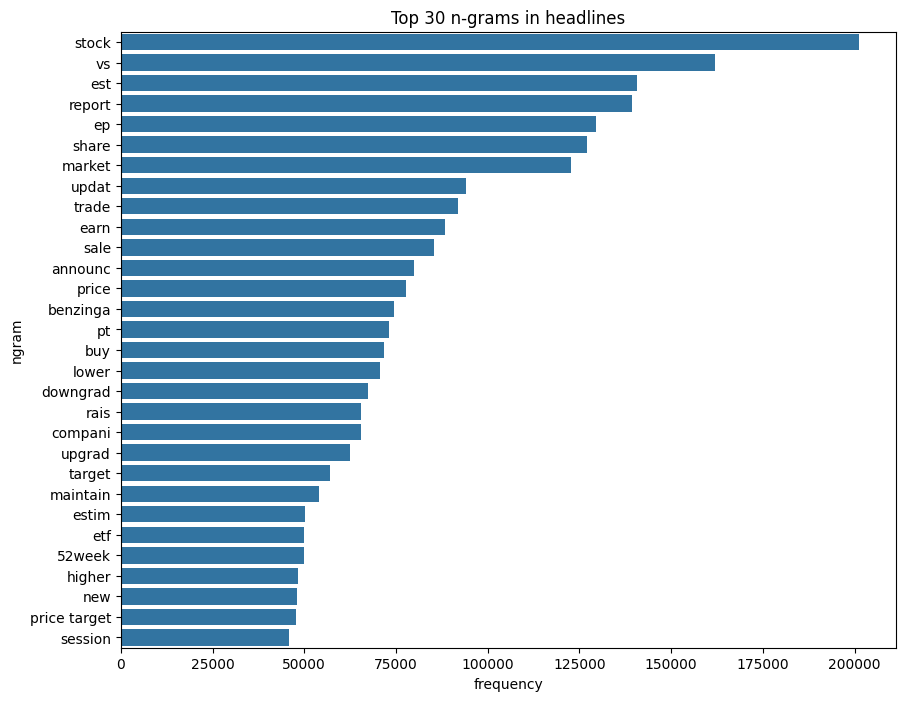

In [42]:
vectorizer = CountVectorizer(ngram_range=(1, 3), min_df=5, max_df=0.7, stop_words='english')
X = vectorizer.fit_transform(df['clean_headline'])

ngram_freq = pd.DataFrame(
    sorted(zip(X.sum(axis=0).tolist()[0], vectorizer.get_feature_names_out()), reverse=True),
    columns=['frequency', 'ngram']
)

print(ngram_freq.head(30))

# Plot top 30
plt.figure(figsize=(10, 8))
sns.barplot(x='frequency', y='ngram', data=ngram_freq.head(30))
plt.title("Top 30 n-grams in headlines")
plt.show()

3.3. TF-IDF version (down-weights very common but boring words across documents)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(ngram_range=(1, 3), min_df=5, max_df=0.7, stop_words='english') # type: ignore
X_tfidf = tfidf.fit_transform(df['clean_headline'])

tfidf_scores = pd.DataFrame(
    X_tfidf.sum(axis=0).tolist()[0],
    index=tfidf.get_feature_names_out(),
    columns=['tfidf_sum']
).sort_values('tfidf_sum', ascending=False)

tfidf_scores.head(30)

,tfidf_sum
stock,21314.54
benzinga,15468.62
market,12732.50
vs,12558.28
est,11447.44
earn,11143.65
report,11062.53
downgrad,10516.89
upgrad,10355.96
ep,10203.89


3.4. Topic Modeling

In [ ]:

from sklearn.decomposition import NMF

# Use only bigrams/trigrams + unigrams, but aggressively limit vocab
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=10,         # appears in at least 10 docs
    max_df=0.5,
    max_features=200_000   # cap vocabulary
)

X_tfidf = vectorizer.fit_transform(df['clean_headline'])

nmf = NMF(n_components=30, random_state=42, init='nndsvd', max_iter=200)
W = nmf.fit_transform(X_tfidf)

def print_nmf_topics(model, vectorizer, top_n=15):
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx}:")
        top_features = [vectorizer.get_feature_names_out()[i] 
                        for i in topic.argsort()[:-top_n-1:-1]]
        print("  " + " | ".join(top_features))

# print_nmf_topics(nmf, vectorizer)

In [126]:
print_nmf_topics(nmf, vectorizer)

Topic 0:
  hit 52week high | 52week high | high | hit 52week | hit | stock hit 52week | stock hit | 52week | stock | 52week high friday | high friday | 52week high thursday | high thursday | high tuesday | 52week high tuesday
Topic 1:
  top upgrad | benzinga top upgrad | upgrad | benzinga top | benzinga | top | upgrad downgrad | top upgrad downgrad | downgrad | 2019 | 2017 | 2018 | upgrad downgrad januari | downgrad januari | 2020
Topic 2:
  friday | move friday | stock move friday | friday premarket | friday premarket session | move friday premarket | stock move | move | session | premarket session | premarket | stock | move friday midday | friday midday session | friday midday
Topic 3:
  biggest mover | mover | biggest mover yesterday | mover yesterday | biggest | yesterday | biggest mover friday | mover friday | friday | 50 biggest mover | 50 biggest | 60 biggest | 60 biggest mover | 60 | 55 biggest
Topic 4:
  est | vs | ep | report | revenu | est revenu | vs est | sale | see | q4 |

## 4. Time Series Analysis

<Axes: xlabel='weekday'>

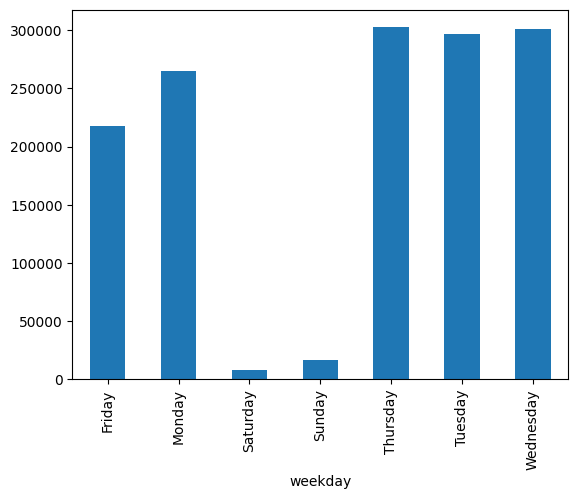

In [24]:
df['weekday'].value_counts().sort_index().plot(kind='bar') 
# higher news frequency on thursday and the lowest in saturday and then sunday

In [29]:
df['hour'] = df['date'].dt.hour
hour_counts = df['hour'].value_counts().sort_index()


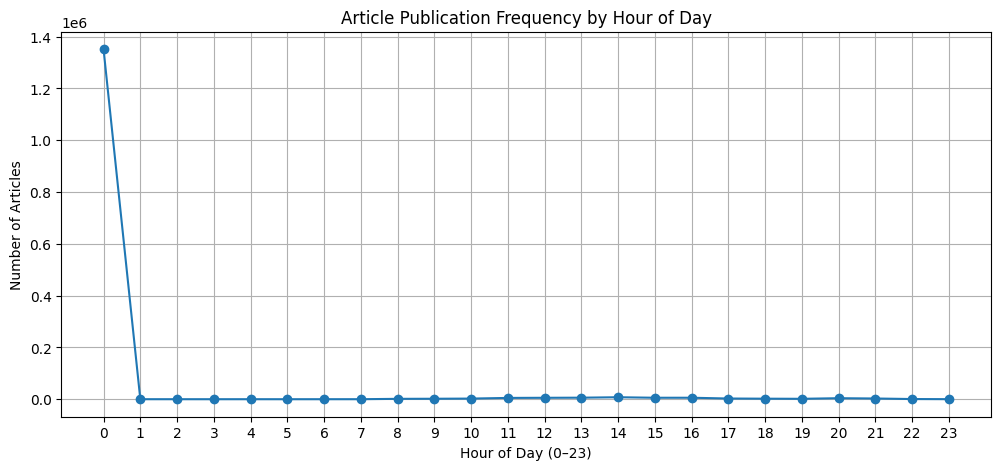

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(hour_counts.index, hour_counts.values, marker='o')

plt.title("Article Publication Frequency by Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Articles")
plt.xticks(range(0,24))   # show all hour ticks
plt.grid(True)

plt.show()





# noticed that most articles are on 0:00 

In [34]:
hour_counts.describe()

count        24.00
mean      58638.67
std      275382.59
min          14.00
25%          90.25
50%        1952.00
75%        5156.50
max     1351472.00
Name: count, dtype: float64

## 5. Publisher Domain Extraction

5.1. High contributors to the news feed

In [ ]:
publisher_counts = df['publisher'].value_counts()

publisher_counts.head(20)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

In [ ]:
# 1. Extract article type from URL
def get_article_type(url):
    if not isinstance(url, str):
        return "unknown"
    path = url.split('benzinga.com/')[-1].split('/')[0] if 'benzinga.com' in url else "external"
    if path.startswith('news'):
        return "General News"
    elif path in ['analyst-ratings', 'trading-ideas']:
        return "Analyst Ratings"
    elif 'movers' in path:
        return "Movers"
    elif 'earnings' in path:
        return "Earnings"
    elif 'options' in path:
        return "Options"
    elif path in ['general-market', 'stock-market-updates']:
        return "Market Summary"
    else:
        return "Other"

df['article_type'] = df['url'].apply(get_article_type)
df['article_type'].value_counts()

article_type
General News       851959
Analyst Ratings    283941
Other              259721
Movers               8841
Options              2866
Name: count, dtype: int64

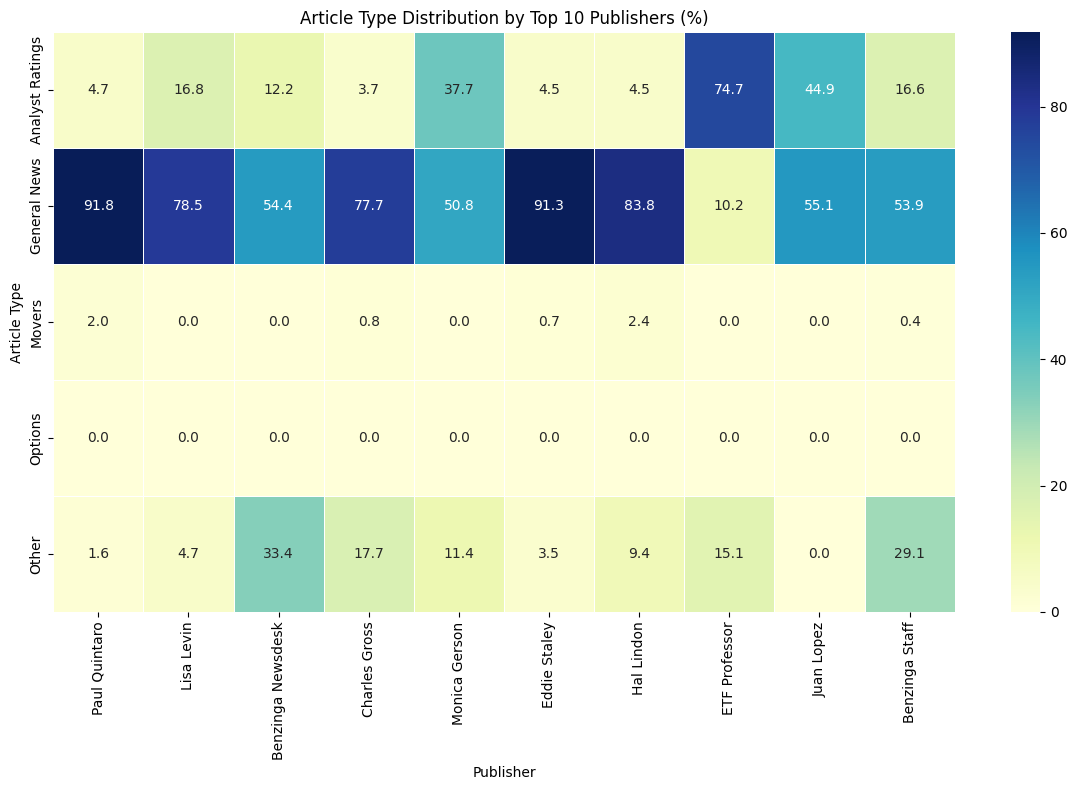

In [ ]:
# 2. Top 10 publishers
top_publishers = df['publisher'].value_counts().head(10).index

# 3. Cross-tab: What type of articles do the top publishers write?
publisher_type = pd.crosstab(df['publisher'], df['article_type'])
publisher_type = publisher_type.loc[top_publishers]  # only top 10

# Normalize to % to see writing style clearly
publisher_type_pct = publisher_type.div(publisher_type.sum(axis=1), axis=0) * 100

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(publisher_type_pct.T, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=.5)
plt.title('Article Type Distribution by Top 10 Publishers (%)')
plt.ylabel('Article Type')
plt.xlabel('Publisher')
plt.tight_layout()
plt.show()

5.2. Unique domain names for email used in publisher names

In [52]:
# Check if any publisher looks like an email
df[df['publisher'].str.contains('@', na=False)]['publisher'].value_counts()

# → will probably print 0 or <10

publisher
luke@benzinga.com                             5198
vishwanath@benzinga.com                       1830
bret.kenwell@benzinga.com                      896
vivek.proactive@gmail.com                      120
richa28dhand@gmail.com                          17
Andy@andyswan.com                                5
newsdesk+benzingastaffwriter3@benzinga.com       3
aefimoff@benzinga.com                            3
shivdeep@benzinga.com                            3
kiana@investdiva.com                             2
andrewbeghou@benzinga.com                        2
andrew@tothetick.com                             2
jennifer25anthony@gmail.com                      2
adam@eosdetroit.io                               1
dhiraj.surapaneni@benzinga.com                   1
javierhasseandericterbush@benzinga.com           1
vic@forextraininggroup.com                       1
official@stockmetrix.net                         1
Name: count, dtype: int64

In [ ]:
# 1. Publisher domain extraction (very important for the task)
df['publisher_domain'] = df['publisher'].str.extract(r'(@[\w\.-]+)')
top_domains = df['publisher_domain'].value_counts().head(10)
top_domains

publisher_domain
@benzinga.com              7937
@gmail.com                  139
@andyswan.com                 5
@investdiva.com               2
@tothetick.com                2
@eosdetroit.io                1
@forextraininggroup.com       1
@stockmetrix.net              1
Name: count, dtype: int64

In [57]:
df[df['publisher'].str.contains('Luke', na=False,case=False)]['publisher'].value_counts()  
# note that some names are duplicated

publisher
luke@benzinga.com    5198
Luke Jacobi          1198
Luke J Jacobi         481
P. Luke LaVanway        3
Name: count, dtype: int64